# GSoC DEEPLENS Evaluation Specific Task VII

## Physics-Informed Neural Network for Gravitational Lensing Classification

**Objective**: Classify gravitational lensing images with three dark matter substructure types (no substructure, spherical substructure , vortex substructure) with a PINN (Physics Informed Neural Network) and compare the performance to a baseline

### Environment Setup & Imports

Import necessary libraries for deep learning (PyTorch), ResNet backbone, metrics, and visualization tools. Set device (GPU/CPU) and random seeds for reproducibility.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## Load Dataset

The Dataset was concatenated from the zip file given by the evaluators into a single files using "build_complete_dataset.py" script
- X_train.npy : (30000, 1, 150, 150)
- y_train.npy : (30000, )
- X_test.npy : (7500, 1, 150, 150)
- y_test.npy : (7500, )

The dataset is structured into three labels 
- 0 : No Substructure
- 1 : Subhalo Substructure
- 2 : Vortex Substructure

In [2]:
X_train = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/X_train.npy')  # (30000, 1, 150, 150)
X_test  = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/X_test.npy')   # (7500,  1, 150, 150)
y_train = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/y_train.npy')  # (30000,)
y_test  = np.load('/kaggle/input/datasets/abhirajraje/lensing-data/y_test.npy')   # (7500,)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')
print(f'Classes: {np.unique(y_train)} | Counts: {np.bincount(y_train.astype(int))}')
print(f'\nData range — min: {X_train.min():.4f}, max: {X_train.max():.4f}')

X_train: (30000, 1, 150, 150), y_train: (30000,)
X_test:  (7500, 1, 150, 150),  y_test:  (7500,)
Classes: [0 1 2] | Counts: [10000 10000 10000]

Data range — min: 0.0000, max: 1.0000


## Visualize Sample Images

Display sample images from each class.

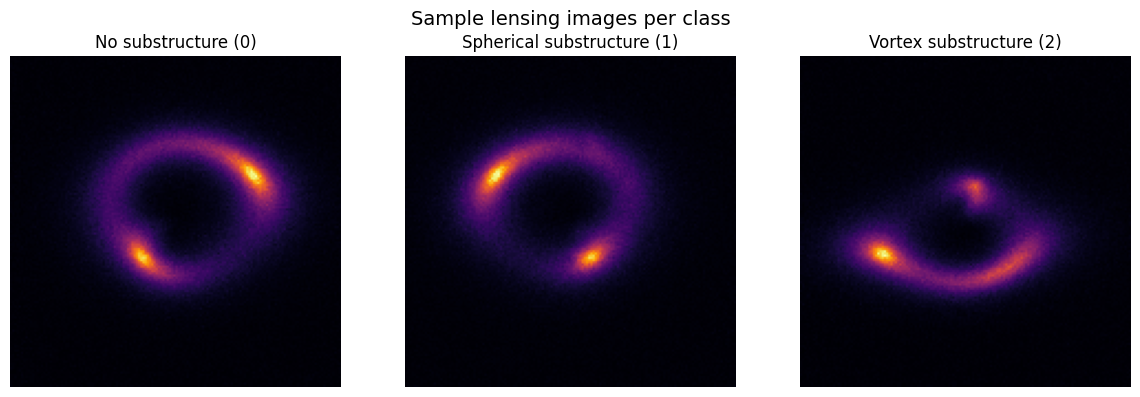

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels_desc = ['No substructure (0)', 'Spherical substructure (1)', 'Vortex substructure (2)']

for cls in range(3):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].imshow(X_train[idx, 0], cmap='inferno')
    axes[cls].set_title(labels_desc[cls])
    axes[cls].axis('off')

plt.suptitle('Sample lensing images per class', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## Create Dataset & DataLoaders

Define a PyTorch Dataset class with on-the-fly data augmentation (horizontal/vertical flips and rotations for training). Create DataLoaders for training and testing with batch size 64.

In [4]:
class LensingDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]

        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[-1])
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[-2])
            k = torch.randint(0, 4, (1,)).item()
            img = torch.rot90(img, k, dims=[-2, -1])

        return img, label


train_dataset = LensingDataset(X_train, y_train, augment=True)
test_dataset  = LensingDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 469 | Test batches: 118


## Differentiable Lensing Simulator

The physics-informed reconstruction loop requires a differentiable forward model — a module that takes predicted lens parameters and a decoded source image, and produces a simulated lensed image comparable against the original input via a reconstruction loss. Gradients must flow back through this module into both the physics head and the source decoder, enabling end-to-end training with no ground-truth physics labels.

We implement a **Singular Isothermal Sphere (SIS)** lens model, the standard first-order approximation for galaxy-scale gravitational lenses. The SIS deflection angle at image-plane position **θ** is:

```
α(θ) = θ_E · (θ - θ_c) / |θ - θ_c|
```

where `θ_E` is the Einstein radius and `θ_c = (cx, cy)` is the lens center. The lens equation then maps each image-plane position to its source-plane position:

```
β = θ - α(θ)
```

This mapping is implemented as a coordinate grid transformation using PyTorch's `F.grid_sample`, which is fully differentiable with respect to both the grid coordinates (and therefore `θ_E, cx, cy`) and the source image pixel values.


> **Note:** The SIS model captures dominant lensing behavior but does not account for ellipticity or external shear. A natural extension is the Singular Isothermal Ellipsoid (SIE), adding axis ratio `q` and position angle `φ` — a proposed direction for future work.

Simulator output shape: torch.Size([2, 1, 150, 150])


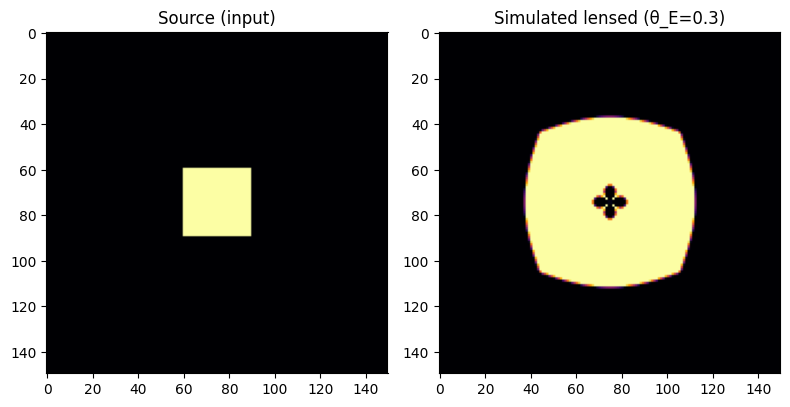

In [ ]:
class LensingSimulator(nn.Module):
    """
    Differentiable SIS gravitational lensing simulator.
    Given physics params (theta_E, cx, cy) and a source image,
    produces a reconstructed lensed image via grid_sample.
    """
    def __init__(self, img_size=150):
        super().__init__()
        self.img_size = img_size
        lin = torch.linspace(-1, 1, img_size)
        yy, xx = torch.meshgrid(lin, lin, indexing='ij')  # (H, W) each
        self.register_buffer('grid_base', torch.stack([xx, yy], dim=-1))  # (H, W, 2)

    def forward(self, source, theta_E, cx, cy):
        """
        source:  (B, 1, H, W)
        theta_E: (B, 1)  — Einstein radius, normalized (0, 0.8)
        cx:      (B, 1)  — lens center x
        cy:      (B, 1)  — lens center y
        returns: (B, 1, H, W)  reconstructed lensed image
        """
        B = source.shape[0]
        grid = self.grid_base.unsqueeze(0).expand(B, -1, -1, -1).clone()

        cx      = cx.view(B, 1, 1, 1)
        cy      = cy.view(B, 1, 1, 1)
        theta_E = theta_E.view(B, 1, 1, 1)

        dx = grid[..., 0:1] - cx
        dy = grid[..., 1:2] - cy
        r  = torch.sqrt(dx**2 + dy**2 + 1e-8) # 1e-8 for stability

        # SIS deflection angle
        alpha_x = theta_E * dx / r
        alpha_y = theta_E * dy / r

        # Lens equation: source position = image position - deflection
        source_x = grid[..., 0:1] - alpha_x
        source_y = grid[..., 1:2] - alpha_y

        sample_grid = torch.cat([source_x, source_y], dim=-1).clamp(-1, 1)

        reconstructed = F.grid_sample(
            source, sample_grid,
            mode='bilinear', padding_mode='zeros', align_corners=True
        )
        return reconstructed


# Sanity test
sim = LensingSimulator()
dummy_source = torch.zeros(2, 1, 150, 150)
dummy_source[:, :, 60:90, 60:90] = 1.0
out = sim(dummy_source,
          torch.tensor([[0.3], [0.2]]),
          torch.tensor([[0.0], [0.0]]),
          torch.tensor([[0.0], [0.0]]))
print(f'Simulator output shape: {out.shape}')  # (2, 1, 150, 150)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(dummy_source[0, 0].numpy(), cmap='inferno')
axes[0].set_title('Source (input)')
axes[1].imshow(out[0, 0].detach().numpy(), cmap='inferno')
axes[1].set_title('Simulated lensed (θ_E=0.3)')
plt.tight_layout()
plt.savefig('lensing_simulator_test.png', dpi=100)
plt.show()

## Physics-Informed Network Architecture

The model is a **multi-task physics-constrained autoencoder**. A shared encoder maps the input lensed image to a latent representation `z`, which is simultaneously decoded by three independent heads. This forces the latent space to be both discriminative (for classification) and physically grounded (for reconstruction through the lensing equation).

### Encoder and bottleneck

A pretrained ResNet18 backbone serves as the encoder, adapted for single-channel input by averaging the first convolution's pretrained RGB weights across the channel dimension. The final classification layer is removed, leaving a `(B, 512, 1, 1)` feature vector which is projected to a 128-dimensional latent `z` via a linear bottleneck with LayerNorm and ReLU.

### Source decoder

The source decoder inverts the bottleneck — it maps `z` back to image space, producing a `1×150×150` source galaxy image (the unlensed source, prior to gravitational deflection). This is a five-stage transposed CNN with BatchNorm and ReLU activations, followed by a Sigmoid output to match the `[0, 1]` range of the min-max scaled input. A final bilinear interpolation ensures exact spatial dimensions.

The predicted source is then passed to the lensing simulator alongside the physics head's output, producing the reconstructed lensed image. The MSE between this reconstruction and the original input is the self-supervised signal that drives the physics loop — no ground-truth lens parameters are required.

### Physics head

A lightweight two-layer MLP maps `z` to three lens parameters. Output activations enforce physically meaningful ranges:

```
θ_E = sigmoid(·) × 0.8        →  Einstein radius  ∈ (0, 0.8)
cx  = tanh(·)    × 0.3        →  lens center x    ∈ (−0.3, 0.3)
cy  = tanh(·)    × 0.3        →  lens center y    ∈ (−0.3, 0.3)
```

### Classifier head

A two-layer MLP with Dropout(0.3) maps `z` directly to class logits over the three dark matter substructure classes (no substructure, spherical, vortex), trained with cross-entropy loss.


> **Note on the encoder:** ResNet18 is used here for its strong pretrained features and simplicity. The architecture is encoder-agnostic — the backbone can be replaced with a Swin Transformer or HEAL-Swin for improved performance on spherical survey data, as explored in prior GSoC works, without any changes to the three heads or the physics loop.

<img src='./architecure.png'>

In [6]:
class SourceDecoder(nn.Module):
    """Upsamples latent z → source galaxy image (1×150×150)"""
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 5 * 5)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,  16,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16,  1,   kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 256, 5, 5)
        x = self.decoder(x)
        return F.interpolate(x, size=(150, 150), mode='bilinear', align_corners=False)


class PhysicsHead(nn.Module):
    """Regresses lensing parameters (theta_E, cx, cy) from latent z"""
    def __init__(self, latent_dim, n_params=3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, n_params)
        )

    def forward(self, z):
        params  = self.head(z)
        theta_E = torch.sigmoid(params[:, 0:1]) * 0.8   # (0, 0.8)
        cx      = torch.tanh(params[:, 1:2]) * 0.3      # (-0.3, 0.3)
        cy      = torch.tanh(params[:, 2:3]) * 0.3
        return theta_E, cx, cy


class PhysicsInformedLensingNet(nn.Module):
    """
    Architecture:
        image → ResNet18 encoder → latent z (128-dim)
            ├── classifier head  → class logits
            ├── physics head     → θ_E, cx, cy
            └── decoder          → source image
                                       ↓
                               lensing simulator
                                       ↓
                              reconstructed image  ← MSE with input
    """
    def __init__(self, latent_dim=128, n_classes=3, pretrained=True):
        super().__init__()

        # ResNet18 backbone adapted for 1-channel input
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        resnet  = models.resnet18(weights=weights)
        orig_w  = resnet.conv1.weight.data
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        resnet.conv1.weight.data = orig_w.mean(dim=1, keepdim=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])  # → (B, 512, 1, 1)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.ReLU()
        )

        # Three heads
        self.classifier   = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )
        self.physics_head = PhysicsHead(latent_dim)
        self.decoder      = SourceDecoder(latent_dim)
        self.simulator    = LensingSimulator(img_size=150)

    def forward(self, x):
        feat   = self.encoder(x)
        z      = self.bottleneck(feat)
        logits = self.classifier(z)
        theta_E, cx, cy = self.physics_head(z)
        source        = self.decoder(z)
        reconstructed = self.simulator(source, theta_E, cx, cy)
        return logits, reconstructed, (theta_E, cx, cy)


model = PhysicsInformedLensingNet(latent_dim=128, pretrained=True).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}')

# Forward pass check
with torch.no_grad():
    dummy = torch.randn(4, 1, 150, 150).to(DEVICE)
    logits, recon, (te, cx, cy) = model(dummy)
print(f'logits: {logits.shape} | recon: {recon.shape} | θ_E range: [{te.min():.3f}, {te.max():.3f}]')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


Total params:     12,715,031
Trainable params: 12,715,031
logits: torch.Size([4, 3]) | recon: torch.Size([4, 1, 150, 150]) | θ_E range: [0.354, 0.393]


## Training Configuration

We set up two-phase training strategy:
- **Phase 1** (8 epochs): Freeze ResNet18 backbone, train task heads only → classifier learns clean features without distraction
- **Phase 2** (42 epochs): Unfreeze all weights, fine-tune end-to-end with lower learning rate and λ_recon warmup from 0 → 6.0

We use AdamW optimizer with cosine annealing scheduler for more stable training and convergence.

In [7]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

PHASE1_EPOCHS = 8   # freeze backbone, train heads only
PHASE2_EPOCHS = 42   # unfreeze all, fine-tune end-to-end
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

def freeze_backbone(model):
    for param in model.encoder.parameters():
        param.requires_grad = False
    print('Backbone frozen — training heads only')

def unfreeze_backbone(model):
    for param in model.encoder.parameters():
        param.requires_grad = True
    print('Backbone unfrozen — full fine-tuning')

freeze_backbone(model)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS, eta_min=1e-5)

print(f'Phase 1: {PHASE1_EPOCHS} epochs | Phase 2: {PHASE2_EPOCHS} epochs')

Backbone frozen — training heads only
Phase 1: 8 epochs | Phase 2: 42 epochs


## Step 8: Multi-Task Loss Function

Define composite loss:
- **L_cls**: CrossEntropyLoss for classification (scale ~1.0)
- **L_recon**: MSE loss for reconstruction fidelity (pixel-level consistency)
- **L_physics**: Soft prior on θ_E to prevent physics head collapse (E[θ_E] ~ 0.3)

Total = L_cls + λ_recon·L_recon + λ_physics·L_physics

λ_recon warmup prevents reconstruction from overwhelming classification during Phase 2.

> **Note :In practise, it is recommended to tune the λ_recon and λ_physics as per the need of the user like hyperparameters, however in this case λ_physics was set at 0.1 to reduce complexity overhead** 

In [3]:
class MultiTaskLoss(nn.Module):
    """
    L_total = L_cls + λ_recon * L_recon + λ_physics * L_physics

    L_cls:     CrossEntropy on class labels
    L_recon:   MSE scaled by image size (150*150) to match cross-entropy scale
               — raw per-pixel MSE is ~0.003, cross-entropy is ~1.0
               — multiplying by 22500 brings them to the same order of magnitude
    L_physics: Soft prior on theta_E to prevent physics head collapse
    λ_recon:   Passed in per-epoch from training loop (warmup schedule)
               — starts at 0, ramps to 50.0 over Phase 2
               — prevents reconstruction loss from overwhelming classification
               — during Phase 1 warm-up (heads only), λ_recon=0 so the
                 classifier gets clean gradients first
    """
    def __init__(self, lambda_recon=0.0, lambda_physics=0.1):
        super().__init__()
        self.lambda_recon   = lambda_recon
        self.lambda_physics = lambda_physics
        self.cls_loss       = nn.CrossEntropyLoss()

    def forward(self, logits, targets, reconstructed, original, physics_params):
        theta_E, cx, cy = physics_params

        # Classification loss — scale ~1.0
        L_cls = self.cls_loss(logits, targets)

        # Reconstruction loss — scale raw MSE ~0.003, after *22500 → ~67

        L_recon = F.mse_loss(reconstructed, original) # Removes * (150 * 150)

        # Physics regularization — soft prior E[theta_E] ~ 0.3
        L_physics = (theta_E - 0.3).pow(2).mean()

        total = (L_cls
                 + self.lambda_recon * L_recon
                 + self.lambda_physics * L_physics)

        return total, {
            'cls':     L_cls.item(),
            'recon':   (L_recon).item(),          # log scaled value for visibility
            'physics': L_physics.item(),
            'lambda_recon': self.lambda_recon      # log so you can track warmup
        }


criterion = MultiTaskLoss(lambda_recon=0.0, lambda_physics=0.1)
print('Loss function ready — λ_recon starts at 0.0, will ramp during Phase 2')

Loss function ready — λ_recon starts at 0.0, will ramp during Phase 2


## Evaluation Function

Computes test loss breakdown and Macro ROC-AUC (macro-averaged one-vs-rest AUC for multi-class classification).

In [9]:
def evaluate(model, loader, criterion, device):
    model.eval()
    all_probs, all_labels = [], []
    total_loss    = 0
    loss_parts    = {'cls': 0, 'recon': 0, 'physics': 0}

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, recon, physics = model(imgs)
            loss, parts = criterion(logits, labels, recon, imgs, physics)

            total_loss += loss.item()
            for k in loss_parts:
                loss_parts[k] += parts[k]

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    y_bin      = label_binarize(all_labels, classes=[0, 1, 2])
    roc_auc    = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')

    n = len(loader)
    return total_loss / n, roc_auc, {k: v / n for k, v in loss_parts.items()}

## Train Model with Two Phases & λ_recon Warmup

Execute the full training loop:
- Phase 1: Train heads only (frozen backbone), λ_recon = 0 → pure classification
- Phase 2: Unfreeze backbone, λ_recon ramps linearly from 0 → LAMBDA_RECON_MAX over first half of phase 2, then holds steady

Track best model by validation ROC-AUC and save checkpoint.

In [10]:
history = {
    'train_loss': [], 'test_loss': [], 'test_roc_auc': [],
    'cls_loss': [], 'recon_loss': [], 'physics_loss': [],
    'lambda_recon': []
}
best_auc, best_epoch = 0.0, 0

LAMBDA_RECON_MAX = 6   # target λ after full warmup
                            # tune this: increase if reconstruction invisible
                            #            decrease if AUC drops significantly

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Test Loss':>9} | "
      f"{'ROC AUC':>8} | {'L_cls':>7} | {'L_recon':>8} | {'L_phys':>7} | {'λ_recon':>8}")
print('-' * 90)

for epoch in range(1, TOTAL_EPOCHS + 1):

    # ── Phase transition ───────────────────────────────────────────────────
    if epoch == PHASE1_EPOCHS + 1:
        unfreeze_backbone(model)
        optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6)
        print(f'\n>>> Phase 2 started at epoch {epoch} — λ_recon warmup begins <<<\n')

    # Compute current λ_recon
    # During Phase 1: λ_recon = 0 (classifier trains cleanly, no physics pressure)
    # During Phase 2: λ_recon ramps linearly from 0 → LAMBDA_RECON_MAX
    #                 over the first half of Phase 2, then holds steady
    if epoch <= PHASE1_EPOCHS:
        current_lambda_recon = 0.0
    else:
        phase2_progress = (epoch - PHASE1_EPOCHS) / PHASE2_EPOCHS  # 0 → 1
        ramp = min(1.0, phase2_progress * 2)                        # reaches 1.0 at halfway
        current_lambda_recon = LAMBDA_RECON_MAX * ramp

    criterion.lambda_recon = current_lambda_recon

    # Training
    model.train()
    train_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits, recon, physics = model(imgs)
        loss, _ = criterion(logits, labels, recon, imgs, physics)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    train_loss /= len(train_loader)

    # Evaluation
    test_loss, roc_auc, parts = evaluate(model, test_loader, criterion, DEVICE)

    if roc_auc > best_auc:
        best_auc, best_epoch = roc_auc, epoch
        torch.save(model.state_dict(), 'best_model.pt')

    # Logging
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['test_roc_auc'].append(roc_auc)
    history['cls_loss'].append(parts['cls'])
    history['recon_loss'].append(parts['recon'])
    history['physics_loss'].append(parts['physics'])
    history['lambda_recon'].append(current_lambda_recon)

    if epoch % 2 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {test_loss:>9.4f} | "
              f"{roc_auc:>8.4f} | {parts['cls']:>7.4f} | "
              f"{parts['recon']:>8.4f} | {parts['physics']:>7.4f} | "
              f"{current_lambda_recon:>8.5f}")

print(f'\nBest ROC AUC: {best_auc:.4f} at epoch {best_epoch}')

 Epoch | Train Loss | Test Loss |  ROC AUC |   L_cls |  L_recon |  L_phys |  λ_recon
------------------------------------------------------------------------------------------
     1 |     1.0984 |    1.0952 |   0.5415 |  1.0952 |   0.2782 |  0.0000 |  0.00000
     2 |     1.0945 |    1.0939 |   0.5529 |  1.0939 |   0.2789 |  0.0000 |  0.00000
     4 |     1.0907 |    1.0902 |   0.5529 |  1.0902 |   0.2779 |  0.0000 |  0.00000
     6 |     1.0893 |    1.0888 |   0.5549 |  1.0888 |   0.2774 |  0.0000 |  0.00000
     8 |     1.0864 |    1.0875 |   0.5576 |  1.0875 |   0.2776 |  0.0000 |  0.00000
Backbone unfrozen — full fine-tuning

>>> Phase 2 started at epoch 9 — λ_recon warmup begins <<<

    10 |     0.7329 |    0.7134 |   0.8767 |  0.7020 |   0.0149 |  0.0288 |  0.57143
    12 |     0.5035 |    0.4798 |   0.9392 |  0.4694 |   0.0085 |  0.0066 |  1.14286
    14 |     0.3991 |    0.3854 |   0.9605 |  0.3745 |   0.0063 |  0.0015 |  1.71429
    16 |     0.3456 |    0.3521 |   0.9655 |  

## Visualize Training Curves

We plot four monitoring plots: total loss, ROC-AUC, loss component breakdown (L_cls, L_recon, L_physics), and λ_recon warmup schedule. Mark the Phase 1 → Phase 2 transition.

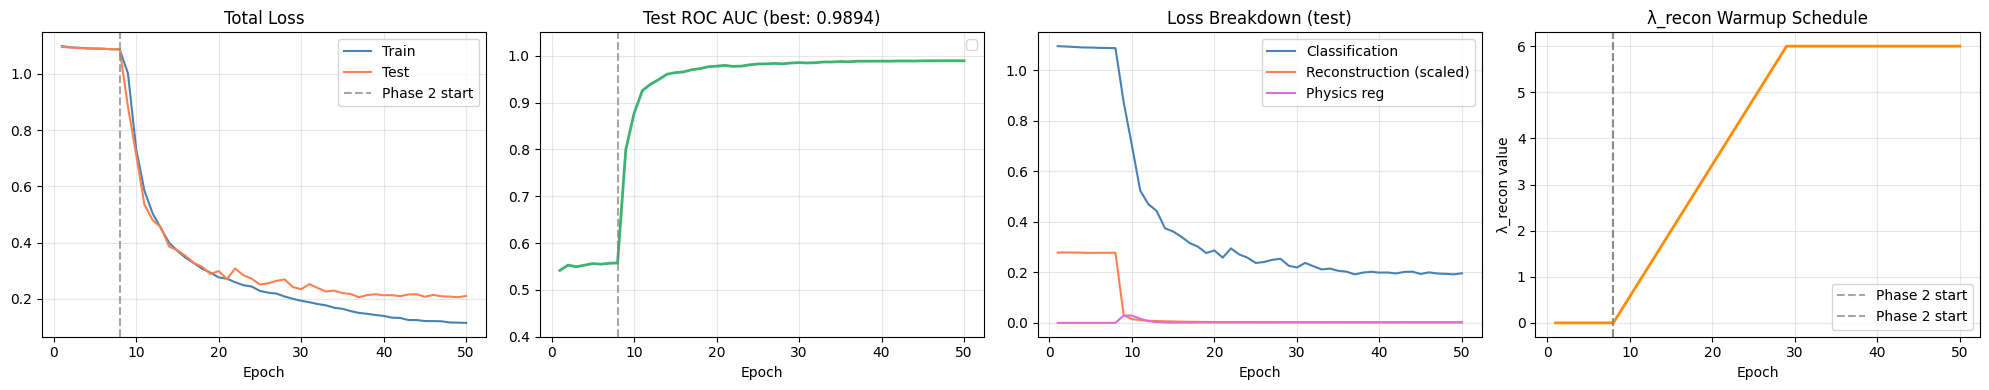

Final λ_recon: 6.00000
Final L_recon (scaled): 0.0022
Final L_cls:            0.1963
Ratio L_recon/L_cls:    0.011


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
epochs = range(1, TOTAL_EPOCHS + 1)

# Total loss
axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs, history['test_loss'],  label='Test',  color='coral')
axes[0].axvline(PHASE1_EPOCHS, ls='--', color='gray', alpha=0.7, label='Phase 2 start')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ROC AUC
axes[1].plot(epochs, history['test_roc_auc'], color='mediumseagreen', lw=2)
axes[1].axvline(PHASE1_EPOCHS, ls='--', color='gray', alpha=0.7)
axes[1].set_title(f'Test ROC AUC (best: {best_auc:.4f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim([0.4, 1.05])
axes[1].legend()
axes[1].grid(alpha=0.3)

# Loss breakdown
axes[2].plot(epochs, history['cls_loss'],     label='Classification', color='steelblue')
axes[2].plot(epochs, history['recon_loss'],   label='Reconstruction (scaled)', color='coral')
axes[2].plot(epochs, history['physics_loss'], label='Physics reg',    color='orchid')
axes[3].axvline(PHASE1_EPOCHS, ls='--', color='gray', alpha=0.7, label='Phase 2 start')
axes[2].set_title('Loss Breakdown (test)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

# λ_recon warmup schedule
axes[3].plot(epochs, history['lambda_recon'], color='darkorange', lw=2)
axes[3].axvline(PHASE1_EPOCHS, ls='--', color='gray', alpha=0.7, label='Phase 2 start')
axes[3].set_title('λ_recon Warmup Schedule')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('λ_recon value')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Final λ_recon: {history["lambda_recon"][-1]:.5f}')
print(f'Final L_recon (scaled): {history["recon_loss"][-1]:.4f}')
print(f'Final L_cls:            {history["cls_loss"][-1]:.4f}')
print(f'Ratio L_recon/L_cls:    {history["recon_loss"][-1]/history["cls_loss"][-1]:.3f}')

## Plot ROC Curves

Load the best model checkpoint and generate ROC curves for each of the 3 classes (one-vs-rest). Compute and display AUC scores.

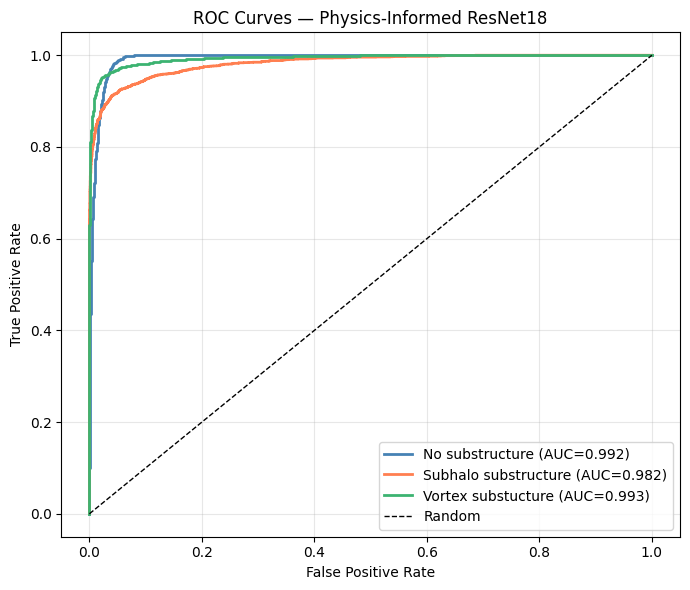

In [12]:
from sklearn.metrics import roc_curve, auc

model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits, _, _ = model(imgs.to(DEVICE))
        all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
y_bin      = label_binarize(all_labels, classes=[0, 1, 2])

class_names = ['No substructure', 'Subhalo substructure', 'Vortex substucture']
colors      = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(7, 6))
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Physics-Informed ResNet18')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Visualize Input → Decoded → Reconstructed Pipeline

We show the three-stage transformation for 6 test samples to test model performance:
1. Original lensed image (input)
2. Decoded source galaxy (z → decoder → source)
3. Reconstructed lensed image (source → simulator → lensed output)

We display predicted class, true class, and learned physics parameters (θ_E, cx, cy) for each sample.

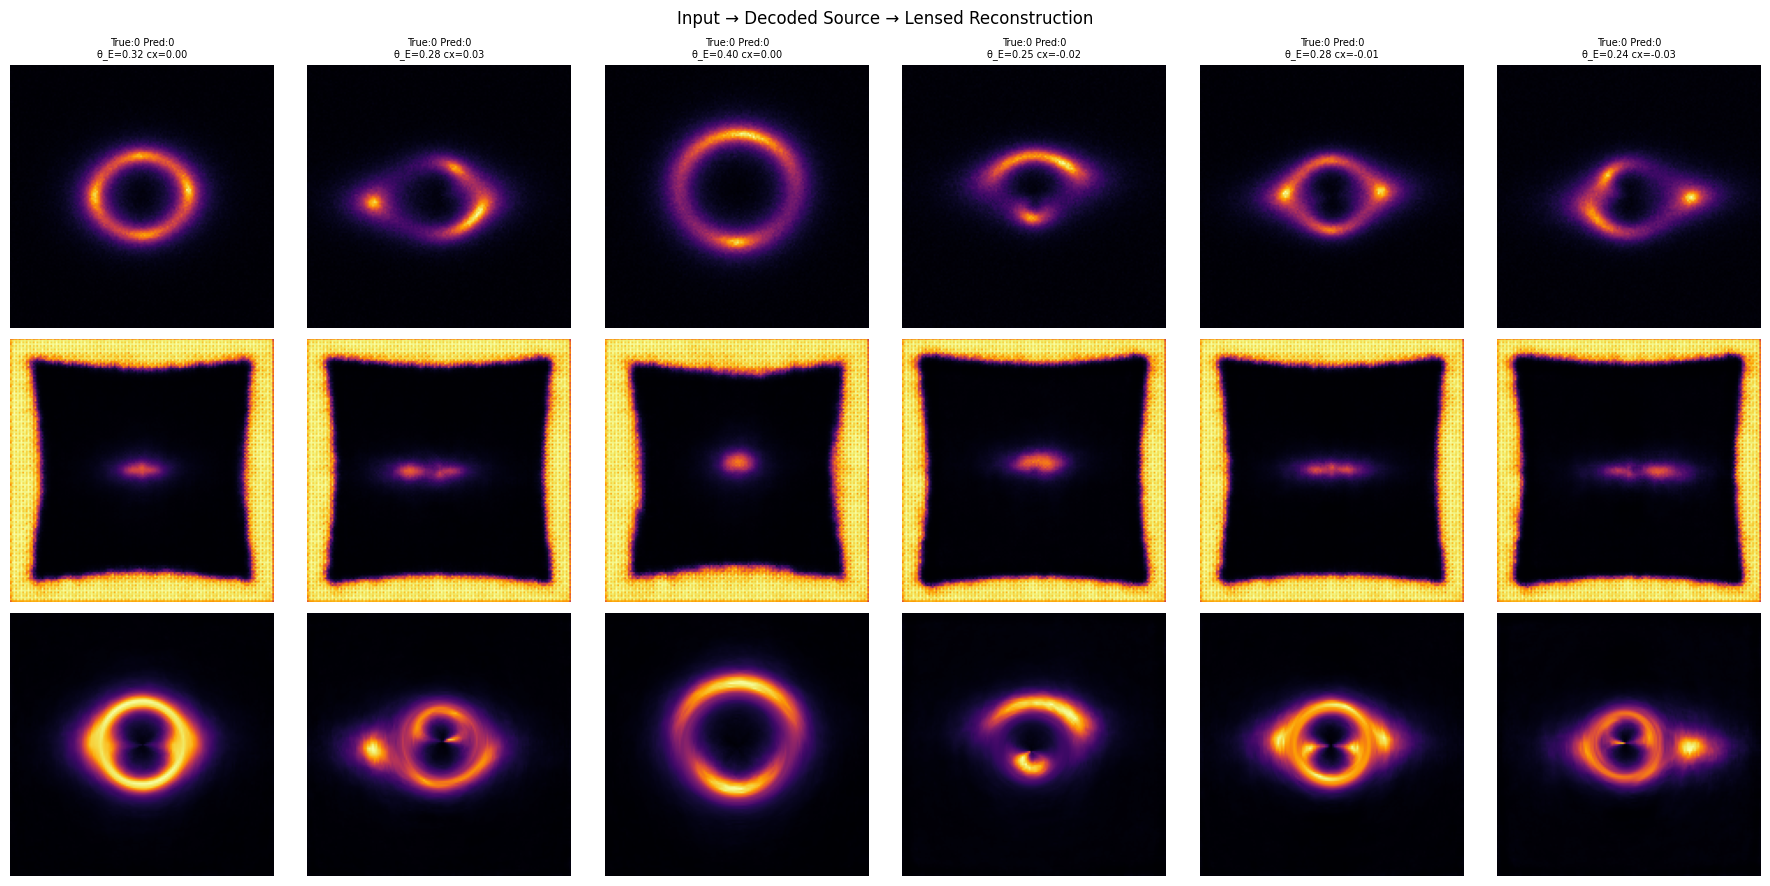

In [13]:
model.eval()
sample_imgs, sample_labels = next(iter(test_loader))
sample_imgs = sample_imgs[:6].to(DEVICE)

with torch.no_grad():
    logits, recon, (theta_E, cx, cy) = model(sample_imgs)
    feat   = model.encoder(sample_imgs)
    z      = model.bottleneck(feat)
    source = model.decoder(z)

pred_classes = torch.argmax(logits, dim=1).cpu().numpy()
true_classes = sample_labels[:6].numpy()
theta_E_vals = theta_E.cpu().numpy().flatten()
cx_vals      = cx.cpu().numpy().flatten()
cy_vals      = cy.cpu().numpy().flatten()

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
row_labels = ['Input image', 'Decoded source', 'Reconstructed (lensed)']
data_rows  = [sample_imgs, source, recon]

for j in range(6):
    for row in range(3):
        axes[row, j].imshow(data_rows[row][j, 0].cpu().numpy(), cmap='inferno')
        axes[row, j].axis('off')
    axes[0, j].set_title(
        f'True:{true_classes[j]} Pred:{pred_classes[j]}\n'
        f'θ_E={theta_E_vals[j]:.2f} cx={cx_vals[j]:.2f}',
        fontsize=7
    )

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9)

plt.suptitle('Input → Decoded Source → Lensed Reconstruction', fontsize=12)
plt.tight_layout()
plt.savefig('reconstructions.png', dpi=120, bbox_inches='tight')
plt.show()

## Analyze Learned Physics Parameters by Class

We visualize the learned physics parameters (θ_E, cx, cy) across all test samples, stratified by dark matter class. We compute mean and standard deviation to check if the model discovers class-specific physics signatures.


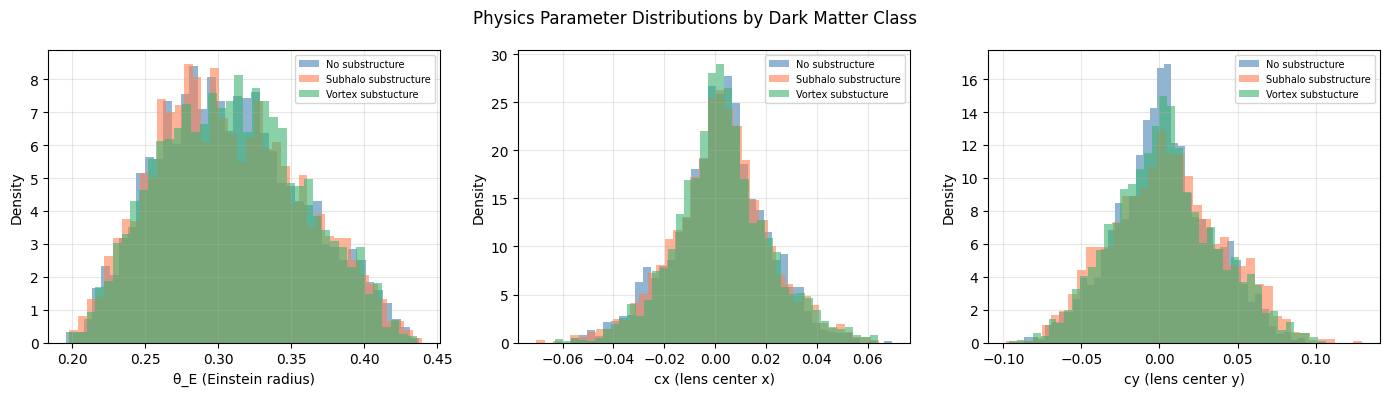

No substructure: θ_E mean=0.308  std=0.049
Subhalo substructure: θ_E mean=0.307  std=0.049
Vortex substucture: θ_E mean=0.309  std=0.048


In [14]:
# Visualising the parameters
all_theta_E, all_cx, all_cy, all_true = [], [], [], []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        z = model.bottleneck(model.encoder(imgs.to(DEVICE)))
        theta_E, cx, cy = model.physics_head(z)
        all_theta_E.append(theta_E.cpu().numpy().flatten())
        all_cx.append(cx.cpu().numpy().flatten())
        all_cy.append(cy.cpu().numpy().flatten())
        all_true.append(labels.numpy())

all_theta_E = np.concatenate(all_theta_E)
all_cx      = np.concatenate(all_cx)
all_cy      = np.concatenate(all_cy)
all_true    = np.concatenate(all_true)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
params   = [all_theta_E, all_cx, all_cy]
p_labels = ['θ_E (Einstein radius)', 'cx (lens center x)', 'cy (lens center y)']

for ax, param, plabel in zip(axes, params, p_labels):
    for cls, (name, color) in enumerate(zip(class_names, colors)):
        mask = (all_true == cls)
        ax.hist(param[mask], bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_xlabel(plabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Physics Parameter Distributions by Dark Matter Class', fontsize=12)
plt.tight_layout()
plt.savefig('physics_params_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

# Mean and Standard Deviations
for cls, name in enumerate(class_names):
    mask = (all_true == cls)
    print(f'{name}: θ_E mean={all_theta_E[mask].mean():.3f}  std={all_theta_E[mask].std():.3f}')

## Train Baseline ResNet18 for Comparison

We train a standard ResNet18 classifier (no physics head, no decoder, no simulator) on the same data for 50 epochs using CrossEntropyLoss only. Track ROC-AUC to compare against the physics-informed model.

In [15]:
class BaselineResNet18(nn.Module):
    def __init__(self, n_classes=3, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        resnet  = models.resnet18(weights=weights)
        orig_w  = resnet.conv1.weight.data
        resnet.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        resnet.conv1.weight.data = orig_w.mean(dim=1, keepdim=True)
        resnet.fc = nn.Linear(512, n_classes)
        self.model = resnet

    def forward(self, x):
        return self.model(x)


baseline      = BaselineResNet18(pretrained=True).to(DEVICE)
baseline_opt  = optim.AdamW(baseline.parameters(), lr=3e-4, weight_decay=1e-4)
baseline_sch  = CosineAnnealingLR(baseline_opt, T_max=TOTAL_EPOCHS, eta_min=1e-5)
baseline_crit = nn.CrossEntropyLoss()
baseline_aucs = []

print('Training baseline ResNet18...')
for epoch in range(1, TOTAL_EPOCHS + 1):
    baseline.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        baseline_opt.zero_grad()
        baseline_crit(baseline(imgs), labels).backward()
        baseline_opt.step()
    baseline_sch.step()

    baseline.eval()
    probs_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            p = torch.softmax(baseline(imgs.to(DEVICE)), 1).cpu().numpy()
            probs_all.append(p)
            labels_all.append(labels.numpy())

    probs_all  = np.concatenate(probs_all)
    labels_all = np.concatenate(labels_all)
    y_b        = label_binarize(labels_all, classes=[0, 1, 2])
    baseline_aucs.append(roc_auc_score(y_b, probs_all, average='macro', multi_class='ovr'))

    if epoch % 5 == 0:
        print(f'  Epoch {epoch:>3} | Baseline AUC: {baseline_aucs[-1]:.4f}')

print(f'\nBaseline best: {max(baseline_aucs):.4f}')
print(f'Ours best:     {best_auc:.4f}')
print(f'Delta:        +{best_auc - max(baseline_aucs):.4f}')

Training baseline ResNet18...
  Epoch   5 | Baseline AUC: 0.9702
  Epoch  10 | Baseline AUC: 0.9827
  Epoch  15 | Baseline AUC: 0.9885
  Epoch  20 | Baseline AUC: 0.9907
  Epoch  25 | Baseline AUC: 0.9918
  Epoch  30 | Baseline AUC: 0.9937
  Epoch  35 | Baseline AUC: 0.9940
  Epoch  40 | Baseline AUC: 0.9949
  Epoch  45 | Baseline AUC: 0.9950
  Epoch  50 | Baseline AUC: 0.9953

Baseline best: 0.9953
Ours best:     0.9894
Delta:        +-0.0059


## Step 16: Final Comparison — Physics-Informed vs Baseline

We plot ROC-AUC evolution curves over 50 epochs for both models. Show Phase 2 transition marker and compute the performance delta (improvement from physics-informed constraints).

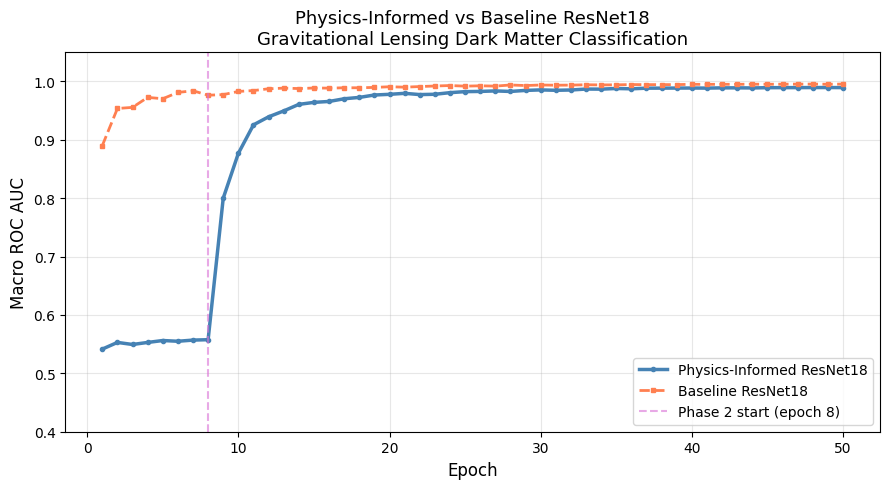


=== Final Summary ===
Baseline ResNet18:         0.9953
Physics-Informed ResNet18: 0.9894
Delta:                    +-0.0059


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
epochs = range(1, TOTAL_EPOCHS + 1)

ax.plot(epochs, history['test_roc_auc'], label='Physics-Informed ResNet18',
        color='steelblue', lw=2.5, marker='o', markersize=3)
ax.plot(epochs, baseline_aucs, label='Baseline ResNet18',
        color='coral', lw=2, ls='--', marker='s', markersize=3)

ax.axvline(PHASE1_EPOCHS, ls='--', color='orchid', alpha=0.6,
           label=f'Phase 2 start (epoch {PHASE1_EPOCHS})')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Macro ROC AUC', fontsize=12)
ax.set_title('Physics-Informed vs Baseline ResNet18\n'
             'Gravitational Lensing Dark Matter Classification', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim([0.4, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== Final Summary ===')
print(f'Baseline ResNet18:         {max(baseline_aucs):.4f}')
print(f'Physics-Informed ResNet18: {best_auc:.4f}')
print(f'Delta:                    +{best_auc - max(baseline_aucs):.4f}')

## Conclusion

We observe that
- Baseline ROC-AUC : 0.9953
- Physics Informed ROC-AUC : 0.9894

We can conclude that:
- The PINN performs similar to the baseline model,where there was not much room for improvement since a ROC-AUC of 0.9953 is already great and the PINN comes close to that (ROC-AUC : 0.9894). 
- However, the PINN gives much better interpretability and scalability as compared to the baseline model while still achieving great performance.
- It can also be noted that the PINN converges to the optimum solution as compared to the Baseline Model